In [1]:
import math
from sympy import *
init_printing()

元の行列 A:


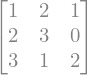

行列式 Determinant of A:


余因子行列 (Cofactor Matrix):


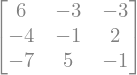

元の行列 A:


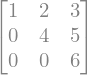

行列式 Determinant of A:


余因子行列 (Cofactor Matrix):


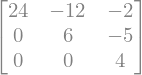

元の行列 A:


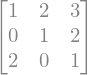

行列式 Determinant of A:


余因子行列 (Cofactor Matrix):


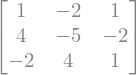

元の行列 A:


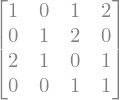

行列式 Determinant of A:


余因子行列 (Cofactor Matrix):


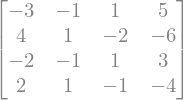

In [15]:
mtxs = [
    Matrix([[1, 2, 1],
            [2, 3, 0],
            [3, 1, 2]]),
    Matrix([[1, 2, 3],
            [0, 4, 5],
            [0, 0, 6]]),
    Matrix([[1, 2, 3],
            [0, 1, 2],
            [2, 0, 1]]),
    Matrix([[1, 0, 1, 2],
            [0, 1, 2, 0],
            [2, 1, 0, 1],
            [0, 0, 1, 1]]),
]

for A in mtxs:
    print("元の行列 A:")
    display(A)
    
    print("行列式 Determinant of A:")
    display(A.det())
    
    print("余因子行列 (Cofactor Matrix):")
    display(A.adjugate())
#    display(A.cofactor_matrix())

    print("=================================")
    # print("逆行列 (Inverse Matrix):")
    # display(inverse_matrix)

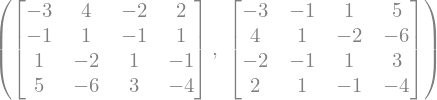

In [14]:
A=Matrix([[1, 0, 1, 2],
            [0, 1, 2, 0],
            [2, 1, 0, 1],
            [0, 0, 1, 1]])
A.cofactor_matrix(), A.adjugate()

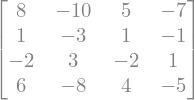

In [17]:
A*(A.cofactor_matrix())

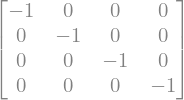

In [18]:
A*(A.adjugate())

1. すべての余因子の定義式（行列形式）:


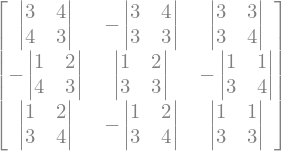


2. 各余因子の計算結果（余因子行列）:


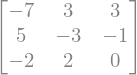


2. 連立方程式の解:


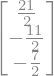

In [33]:
# 行列のサイズ（4x4）を取得
A, v = Matrix([[1,1,2],[3,3,4],[3,4,3]]), Matrix([-2,1,-1])
#Matrix([[1,3,1],[3,5,2],[1,-2,-3]]), Matrix([0,2,-3])
#Matrix([[1,-2,-1],[0,1,2],[-1,0,-2]]), Matrix([1,-1,2])
rows, cols = A.shape

# 表示用の「定義行列」と「結果行列」を初期化
def_matrix_list = []
val_matrix_list = []

rows, cols = A.shape

for i in range(rows):
    def_row = []
    val_row = []
    for j in range(cols):
        sign = (-1)**(i + j)
        minor_matrix = A.minor_submatrix(i, j)
        det_expr = Determinant(minor_matrix)
        
        # 定義式（符号 + 行列式記号）
        definition_expr = det_expr if sign == 1 else -det_expr
        def_row.append(definition_expr)
        
        # 計算結果
        cofactor_val = A.cofactor(i, j)
        val_row.append(cofactor_val)
        
    def_matrix_list.append(def_row)
    val_matrix_list.append(val_row)

# SymPyのMatrixオブジェクトに変換
Cofactor_Definition_Matrix = Matrix(def_matrix_list)
Cofactor_Value_Matrix = Matrix(val_matrix_list)

# 綺麗に並べて表示
print("1. すべての余因子の定義式（行列形式）:")
display(Cofactor_Definition_Matrix)

print("\n2. 各余因子の計算結果（余因子行列）:")
display(Cofactor_Value_Matrix)

print("\n2. 連立方程式の解:")
display((1/A.det())*(Cofactor_Value_Matrix.T)*v)

In [53]:
# 記号変数を定義（小文字の symbols を使用します）
a, b, c = symbols('a b c')

# 行列を定義
#M = Matrix([[0, a**2, b**2, 1],[a**2, 0, c**2, 1],[b**2, c**2, 0, 1],[1, 1, 1, 0]])
#Matrix([[a, a, a, b],[b, b, a, b],[b, a, b, b],[b, a, a, a]])
#Matrix([[a, b, c],[c, a, b],[b, c, a]])
M = Matrix([[a, a, b],
            [a, b, a],
            [b, a, a]])

# 行列式を計算し、綺麗に因数分解（factor）して表示
determinant_expr = M.det()

print("行列式（展開形）:")
display(determinant_expr)

print("\n行列式（因数分解形）:")
display(determinant_expr.factor())

行列式（展開形）:



行列式（因数分解形）:


In [50]:
myexpr = (c**2-a**2-b**2)**2-4*a**2*b**2
display(determinant_expr.factor(), myexpr.factor())

#display(myexpr.factor())

【初期状態】行列 M:


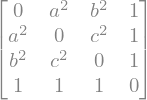


【ステップ1】第4行を使って、第1列の要素を掃き出す:


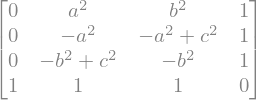


【ステップ2】第4列を使って、第4行の要素を掃き出す（4行4列目が 1 になります）:


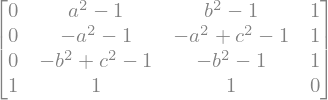


【ステップ3】余因子展開により得られた 3x3 小行列:


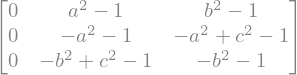


【最終結果】3x3行列式を展開した形:



【最終結果】綺麗に因数分解された形:


In [51]:
from sympy import *
init_printing()

# 記号変数の定義
a, b, c = symbols('a b c')

# 元の行列 M の定義
M = Matrix([[0, a**2, b**2, 1],
            [a**2, 0, c**2, 1],
            [b**2, c**2, 0, 1],
            [1, 1, 1, 0]])

print("【初期状態】行列 M:")
display(M)

# --------------------------------------------------
# ステップ 1: 第4行を使って、第4列の「1」たちを掃き出す（消去する）
# --------------------------------------------------
# 行列式の性質より、ある行の定数倍を他の行に足しても行列式の値は変わりません。
# 1行目 = 1行目 - 4行目 * 0  (変化なし)
# 2行目 = 2行目 - 4行目 * a^2
# 3行目 = 3行目 - 4行目 * b^2
M1 = M.copy()
M1[1, :] = M1[1, :] - a**2 * M1[3, :]
M1[2, :] = M1[2, :] - b**2 * M1[3, :]

print("\n【ステップ1】第4行を使って、第1列の要素を掃き出す:")
display(M1)

# --------------------------------------------------
# ステップ 2: 第4列を使って、第4行の「1」たちを掃き出す
# --------------------------------------------------
# 列基本変形も行列式の値を変化させません。
# 2列目 = 2列目 - 4列目 * 1
# 3列目 = 3列目 - 4列目 * 1
M2 = M1.copy()
M2[:, 1] = M2[:, 1] - M2[:, 3] * 1
M2[:, 2] = M2[:, 2] - M2[:, 3] * 1

print("\n【ステップ2】第4列を使って、第4行の要素を掃き出す（4行4列目が 1 になります）:")
display(M2)

# --------------------------------------------------
# ステップ 3: 余因子展開 (4行4列目の '1' を基準に展開)
# --------------------------------------------------
# 4行4列目の成分は1、その位置の符号は (-1)^(4+4) = 1 です。
# したがって、4行目と4列目を取り除いた 3x3 行列の行列式に帰着します。
M_sub = M2.minor_submatrix(3, 3)

print("\n【ステップ3】余因子展開により得られた 3x3 小行列:")
display(M_sub)

# --------------------------------------------------
# ステップ 4: 最終的な行列式の計算と因数分解
# --------------------------------------------------
det_final = M_sub.det()

print("\n【最終結果】3x3行列式を展開した形:")
display(det_final)

print("\n【最終結果】綺麗に因数分解された形:")
display(det_final.factor())

In [54]:
from math import gcd
from collections import Counter, defaultdict

def F(X,Y,lam_num,lam_den): # lambda = lam_num/lam_den = r/gamma
    x,y=X,Y
    steps=0
    while y>0:
        # floor((X - r/gamma)/Y)=floor((gamma X-r)/(gamma Y)) = floor((den*x-num)/(den*y))
        q=(lam_den*x-lam_num)//(lam_den*y)
        xn=x-q*y
        yn=y-xn
        x,y=xn,yn
        steps+=1
        if steps>10000: raise RuntimeError
    return x,-y,steps

# sample for r/gamma in (2,3], i.e r/gamma = k/g with r, gamma gcd? use pairs
for r in range(6,31):
    gs=[g for g in range(1,r) if 3*g>=r and 2*g<r]
    if not gs: continue
    print('\nr',r,'gammas',gs)
    for gam in gs[:10]:
        cnt=Counter(); mods=defaultdict(Counter); mods2=defaultdict(Counter)
        examples={1:[],2:[]}
        for X in range(1,80):
            for Y in range(1,80):
                if gcd(X,Y)!=1: continue
                # Need original c=gamma X-r positive? c can be positive -> gamma X > r. d-r=gamma Y positive. so X > lambda
                if gam*X<=r: continue
                B,C,s=F(X,Y,r,gam)
                if C in (1,2):
                    cnt[C]+=1
                    mods[X%2][C]+=1
                    mods2[Y%2][C]+=1
                    if len(examples[C])<3: examples[C].append((X,Y,B,C,s))
                else:
                    print('C not 1/2',r,gam,X,Y,B,C); raise SystemExit
        print(' gamma',gam,'lambda',r/gam,'cnt',cnt,'Xpar',dict(mods),'Ypar',dict(mods2),'ex',examples)
    


r 6 gammas [2]
 gamma 2 lambda 3.0 cnt Counter({2: 1866, 1: 1829}) Xpar {0: Counter({2: 635, 1: 607}), 1: Counter({2: 1231, 1: 1222})} Ypar {1: Counter({2: 1272, 1: 1206}), 0: Counter({1: 623, 2: 594})} ex {1: [(4, 3, 4, 1, 1), (4, 7, 4, 1, 2), (4, 11, 4, 1, 3)], 2: [(4, 1, 3, 2, 1), (4, 5, 3, 2, 2), (4, 9, 3, 2, 3)]}

r 7 gammas [3]
 gamma 3 lambda 2.3333333333333335 cnt Counter({2: 1893, 1: 1855}) Xpar {1: Counter({2: 1258, 1: 1248}), 0: Counter({2: 635, 1: 607})} Ypar {1: Counter({2: 1286, 1: 1219}), 0: Counter({1: 636, 2: 607})} ex {1: [(3, 2, 3, 1, 1), (3, 5, 3, 1, 2), (3, 8, 3, 1, 3)], 2: [(3, 1, 3, 2, 1), (3, 4, 3, 2, 2), (3, 7, 3, 2, 3)]}

r 8 gammas [3]
 gamma 3 lambda 2.6666666666666665 cnt Counter({2: 1893, 1: 1855}) Xpar {1: Counter({2: 1258, 1: 1248}), 0: Counter({2: 635, 1: 607})} Ypar {1: Counter({2: 1286, 1: 1219}), 0: Counter({1: 636, 2: 607})} ex {1: [(3, 2, 3, 1, 1), (3, 5, 3, 1, 2), (3, 8, 3, 1, 3)], 2: [(3, 1, 3, 2, 1), (3, 4, 3, 2, 2), (3, 7, 3, 2, 3)]}

r 9 gamm

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/Tn_C_heatmaps_n3_to_n6.png'

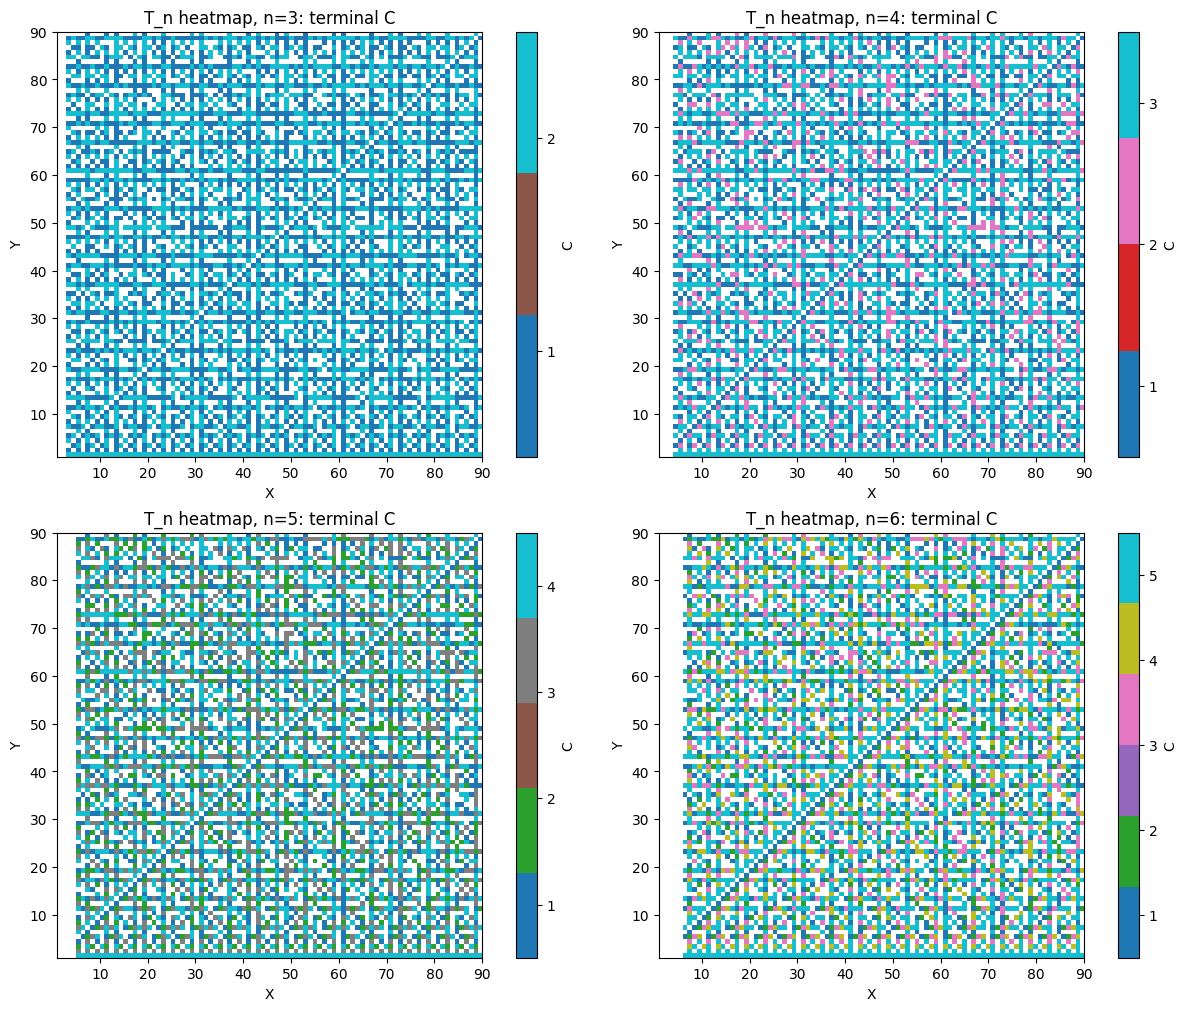

In [55]:
from math import gcd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


def Tn_terminal(n, X, Y, max_iter=10000):
    x, y = int(X), int(Y)
    steps = 0
    while y > 0:
        q = (x - n) // y
        xp = x - q * y
        yp = y - xp
        x, y = xp, yp
        steps += 1
        if steps > max_iter:
            raise RuntimeError((n, X, Y, x, y))
    return x, -y, steps

# 1. C heatmaps for T_n on primitive points
N = 90
ns = [3, 4, 5, 6]
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for ax, n in zip(axes.ravel(), ns):
    grid = np.full((N, N), np.nan)
    for X in range(1, N + 1):
        for Y in range(1, N + 1):
            if X < n or gcd(X, Y) != 1:
                continue
            B, C, s = Tn_terminal(n, X, Y)
            grid[Y - 1, X - 1] = C
    cmap = plt.get_cmap('tab10', max(n, 2))
    im = ax.imshow(grid, origin='lower', extent=[1, N, 1, N], interpolation='nearest', cmap=cmap, vmin=0.5, vmax=n-0.5)
    ax.set_title(f'T_n heatmap, n={n}: terminal C')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    cbar = fig.colorbar(im, ax=ax, ticks=list(range(1, n)))
    cbar.set_label('C')
fig.savefig('/mnt/data/Tn_C_heatmaps_n3_to_n6.png', dpi=220)
print('/mnt/data/Tn_C_heatmaps_n3_to_n6.png')

# 2. Modular slices: fixed X, unit residues colored by C
Xs = [7, 11, 19, 29]
fig2, axes2 = plt.subplots(len(ns), len(Xs), figsize=(15, 10), constrained_layout=True)
for i, n in enumerate(ns):
    for j, X in enumerate(Xs):
        ax = axes2[i, j]
        residues, Cs = [], []
        for Y in range(1, X):
            if gcd(X, Y) == 1 and X >= n:
                B, C, s = Tn_terminal(n, X, Y)
                residues.append(Y)
                Cs.append(C)
        if residues:
            ax.scatter(residues, [1]*len(residues), c=Cs, cmap=plt.get_cmap('tab10', max(n,2)), vmin=0.5, vmax=n-0.5, s=80)
        ax.set_ylim(0.8, 1.2)
        ax.set_yticks([])
        ax.set_xlim(0, X)
        ax.set_xticks(range(1, X))
        ax.tick_params(axis='x', labelsize=7)
        ax.set_title(f'n={n}, X={X}')
        if i == len(ns)-1:
            ax.set_xlabel('Y mod X, units only')
fig2.savefig('/mnt/data/Tn_modular_slices.png', dpi=220)
print('/mnt/data/Tn_modular_slices.png')

# 3. Stern-Brocot forest point cloud: primitive points labeled by terminal boundary C
# Show n=4 and n=5 side by side in (X,Y), points colored by C, with stopping boundaries indicated.
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
for ax, n in zip(axes3, [4, 5]):
    xs, ys, cs = [], [], []
    limit = 80
    for X in range(n, limit+1):
        for Y in range(1, limit+1):
            if gcd(X, Y) != 1:
                continue
            B, C, s = Tn_terminal(n, X, Y)
            xs.append(X); ys.append(Y); cs.append(C)
    sc = ax.scatter(xs, ys, c=cs, s=8, cmap=plt.get_cmap('tab10', max(n,2)), vmin=0.5, vmax=n-0.5, alpha=0.85)
    ax.set_title(f'Stern-Brocot-type forest labels, n={n}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_xlim(n-1, limit+1); ax.set_ylim(0, limit+1)
    cbar = fig3.colorbar(sc, ax=ax, ticks=list(range(1,n)))
    cbar.set_label('root label C')
fig3.savefig('/mnt/data/Tn_forest_pointcloud_n4_n5.png', dpi=220)
print('/mnt/data/Tn_forest_pointcloud_n4_n5.png')

# 4. Small explicit tree skeleton generated backwards from finite roots for n=4
# Roots (B,-C), C=1..3, B=4..7; apply A(q) for q=0,1,2 up to depth 3 and plot edges that enter positive Y region.
def A_apply(q, point):
    x, y = point
    return ((q+1)*x + q*y, x + y)

n = 4
roots = [(B, -C, C) for C in range(1,n) for B in range(n, n+4) if gcd(B, C)==1]
max_depth = 3
q_choices = [0,1,2]
fig4, ax4 = plt.subplots(figsize=(10, 7), constrained_layout=True)
colors = plt.get_cmap('tab10', n)

def rec(point, C, depth):
    x, y = point
    if y >= 0 and x <= 80 and y <= 80:
        ax4.scatter([x],[y], color=colors(C), s=25, zorder=3)
    if depth == max_depth:
        return
    for q in q_choices:
        nx, ny = A_apply(q, point)
        if nx > 90 or ny > 90 or nx < -5 or ny < -5:
            continue
        if y >= 0 or ny >= 0:
            ax4.plot([x,nx],[y,ny], color=colors(C), alpha=0.45, linewidth=1)
        rec((nx,ny), C, depth+1)

for B, negC, C in roots:
    ax4.scatter([B], [negC], color=colors(C), marker='x', s=60)
    ax4.text(B+0.3, negC-0.15, f'C={C}', fontsize=8, color=colors(C))
    rec((B, negC), C, 0)
for C in range(1,n):
    ax4.axhline(-C, color=colors(C), linestyle='--', alpha=0.25)
ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_xlim(0, 80); ax4.set_ylim(-4, 55)
ax4.set_title('Backward-generated Stern-Brocot-type forest skeleton, n=4\nA(q)=R^qL, q=0,1,2, roots on Y=-C')
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
fig4.savefig('/mnt/data/Tn_n4_forest_skeleton.png', dpi=220)
print('/mnt/data/Tn_n4_forest_skeleton.png')

# Summary counts for representative X values, saved text
with open('/mnt/data/Tn_distribution_summary.txt','w') as f:
    for n in ns:
        f.write(f'n={n}\n')
        for X in [7,11,19,29,31]:
            if X < n: continue
            cnt = Counter(Tn_terminal(n, X, Y)[1] for Y in range(1, X) if gcd(X,Y)==1)
            f.write(f'  X={X}, phi={sum(cnt.values())}, counts={dict(sorted(cnt.items()))}\n')
        f.write('\n')
print('/mnt/data/Tn_distribution_summary.txt')